24RB1074 半田悠人

## 演習2（実装）：Cliff Walking で SARSA vs Q学習

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Cliff Walking問題
# SARSAとQ学習の比較

GRID_HEIGHT = 4
GRID_WIDTH = 12

# (0, 0)から(3, 11)までのグリッドワールド
Goal = (GRID_HEIGHT - 1, GRID_WIDTH - 1) 
start = (GRID_HEIGHT - 1, 0) 

S = [(y, x) for y in range(GRID_HEIGHT) for x in range(GRID_WIDTH)]
Cliffs = [(GRID_HEIGHT - 1, x) for x in range(1, GRID_WIDTH - 1)]
A = [
    (1,0), # 下
    (-1,0), # 上
    (0,1), # 右
    (0,-1) # 左
] 

esp = 0.1
alpha = 0.5
gamma = 1.0
num_episodes = 100000

def step(s, a):
    s_next = (s[0] + a[0], s[1] + a[1])
    reward = -1
    
    if s_next not in S:
        s_next = s
        
    if s_next in Cliffs:
        reward = -100
        s_next = start
    
    return s_next, reward

def epsilon_greedy(Q, s, esp):
    a = None
    if np.random.rand() < esp:
        a= np.random.choice(len(A))
    else:
        a = np.argmax(Q[s])
        
    return a

def sarsa(Q_init):
    Q = {s: Q_init[s].copy() for s in S}
    reward_list = []
    
    for episode in range(num_episodes):
        s = start
        a = epsilon_greedy(Q, s, esp)
        total_reward = 0
        
        while s != Goal:
            s_next, r_ = step(s, A[a])
            a_next = epsilon_greedy(Q, s_next, esp)
            
            Q[s][a] += alpha * (r_ + gamma * Q[s_next][a_next] - Q[s][a])
            
            s = s_next
            a = a_next
            total_reward += r_
        
        reward_list.append(total_reward)
        
    return Q, reward_list

def q_learning(Q_init):
    Q = {s: Q_init[s].copy() for s in S}
    reward_list = []
    
    for episode in range(num_episodes):
        s = start
        total_reward = 0
        
        while s != Goal:
            a = epsilon_greedy(Q, s, esp)
            s_next, r_ = step(s, A[a])
            
            Q[s][a] += alpha * (r_ + gamma * np.max(Q[s_next]) - Q[s][a])
            
            s = s_next
            total_reward += r_
        
        reward_list.append(total_reward)
    
    return Q, reward_list

### 1.学習

In [16]:
# Qテーブルを初期化（全状態・全行動の価値を0に設定）
Q_initial = {s: np.zeros(len(A)) for s in S}

# 学習を実行
Q_sarsa, sarsa_rewards = sarsa(Q_initial)
Q_ql, ql_rewards = q_learning(Q_initial)

### 2.経路の可視化

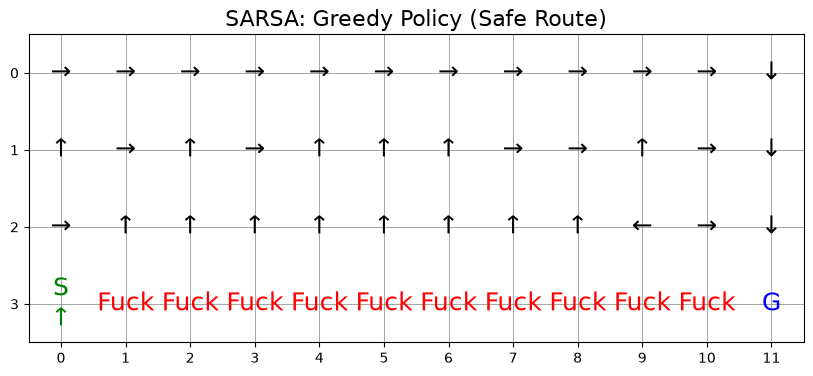

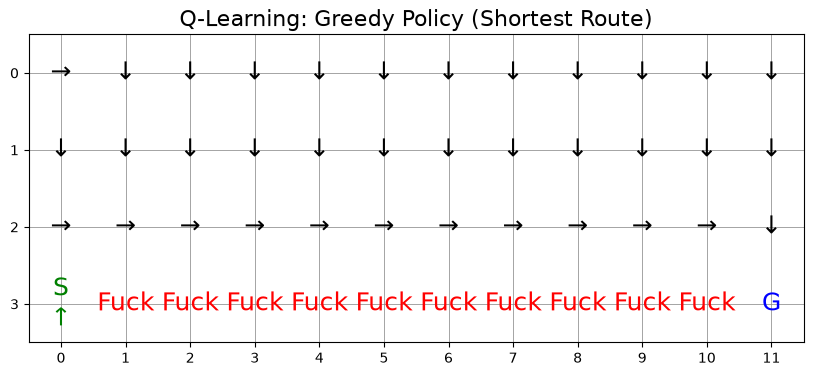

In [17]:
# 矢印
arrow_dict = {(1, 0): '↓', (-1, 0): '↑', (0, 1): '→', (0, -1): '←'}

def visualize_policy(Q, title):
    fig, ax = plt.subplots(figsize=(10, 4))
    
    for row in range(GRID_HEIGHT):
        for col in range(GRID_WIDTH):
            s = (row, col)
            
            # マス目の種類によって表示を変える
            if s == Goal:
                text = 'G'
                color = 'blue'
            elif s in Cliffs:
                text = 'Fuck'
                color = 'red'
            else:
                # 貪欲（greedy）に行動を選択
                best_a_idx = np.argmax(Q[s])
                text = arrow_dict[A[best_a_idx]]
                color = 'black'
                
                # スタート地点は S と矢印を両方表示
                if s == start:
                    text = 'S\n' + text
                    color = 'green'

            # テキストをプロット
            ax.text(col, row, text, ha='center', va='center', fontsize=18, color=color)

    ax.set_title(title, fontsize=16)
    
    # グリッドの見た目を整える
    ax.set_xlim(-0.5, GRID_WIDTH - 0.5)
    ax.set_ylim(-0.5, GRID_HEIGHT - 0.5)
    ax.set_xticks(np.arange(GRID_WIDTH))
    ax.set_yticks(np.arange(GRID_HEIGHT))
    ax.grid(color='gray', linestyle='-', linewidth=0.5)
    
    # Y軸を反転させることで、(3,0)のスタート位置を左下にする
    ax.invert_yaxis()
    plt.show()

# SARSAとQ学習の結果をそれぞれ可視化
visualize_policy(Q_sarsa, 'SARSA: Greedy Policy (Safe Route)')
visualize_policy(Q_ql, 'Q-Learning: Greedy Policy (Shortest Route)')

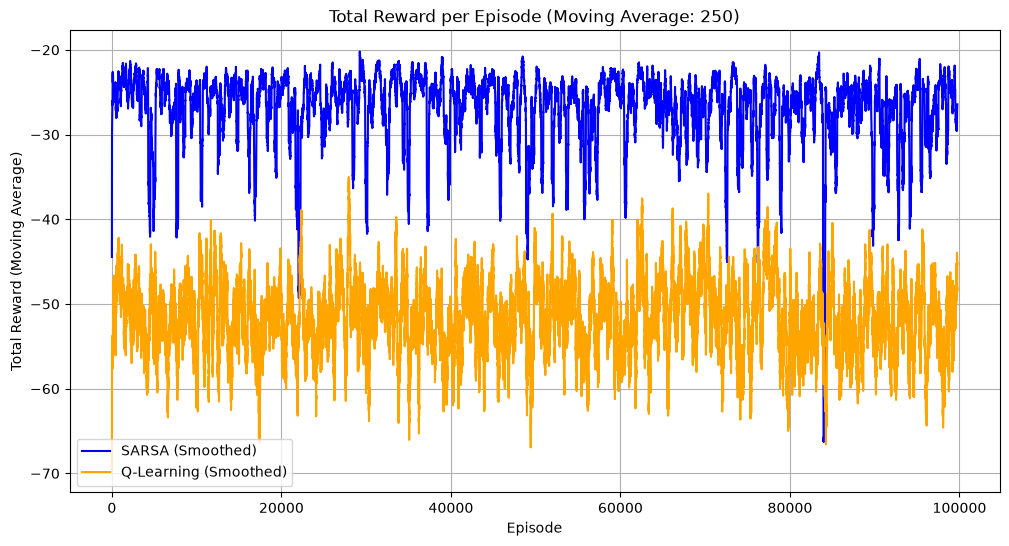

平均報酬 - SARSA: -27.13, Q-Learning: -51.75


In [18]:
def plot_smoothed_rewards(sarsa_rewards, ql_rewards, window=100):
    # 指定した区間（window）の移動平均を計算
    sarsa_smooth = np.convolve(sarsa_rewards, np.ones(window)/window, mode='valid')
    ql_smooth = np.convolve(ql_rewards, np.ones(window)/window, mode='valid')
    
    plt.figure(figsize=(12, 6))
    plt.plot(sarsa_smooth, label='SARSA (Smoothed)', color='blue')
    plt.plot(ql_smooth, label='Q-Learning (Smoothed)', color='orange')
    
    plt.xlabel('Episode')
    plt.ylabel('Total Reward (Moving Average)')
    plt.title(f'Total Reward per Episode (Moving Average: {window})')
    plt.legend()
    plt.grid()
    plt.show()

# スムージングしてプロットを実行
plot_smoothed_rewards(sarsa_rewards, ql_rewards, window=250)

print(f"平均報酬 - SARSA: {np.mean(sarsa_rewards):.2f}, Q-Learning: {np.mean(ql_rewards):.2f}")

## 観察と考察

### 観察
SARSAの方策では、スタート地点から崖に隣接する行を避け、上側へ迂回してゴールへ向かう安全な経路が得られた。一方、Q学習では、スタートから1マス上へ移動した後、崖のすぐ上を右へ進む最短経路が得られた。

250エピソードの移動平均を見ると、SARSAの合計報酬はおよそ $-25$ 、Q学習は $-50$ で推移している。全エピソードの平均報酬も、SARSAが $-26.62$、Q学習が $-51.79$ であり、今回の実行ではSARSAの方が高い報酬を得た。また、学習回数を増やしても両者の報酬には変動が残っている。

### 考察
SARSAは、オンポリシー手法であるため、探索によって誤って崖へ進む可能性も含めて学習し、遠回りでも安全な経路を選択したと考えられる。安全な経路は通常時の歩数は多くなるが、報酬 $-100$ を受ける転落を減らせるため、実際に行動した際の平均報酬は高くなった。

これに対してQ学習は、オフポリシー手法であるため、探索を行わない貪欲方策としては、崖の直上を通る最短経路を学習する。しかし、学習中の行動選択には $\epsilon=0.1$ の探索が残っているので、崖の近くでランダムな下方向の行動を選ぶと転落し、大きな負の報酬を受ける。この転落の影響により、最短経路を学習しているにもかかわらず、学習中の平均報酬はSARSAより低くなったと考えられる。

報酬の変動が最後まで残る理由も、探索率 $\epsilon$ を一定にしているためと予想される。